<a href="https://colab.research.google.com/github/msussman42/CQE/blob/main/LSTM_ODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - loss: 0.0395 - val_loss: 2.4021e-04 - learning_rate: 0.0010
Epoch 2/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 7.6490e-04 - val_loss: 1.1730e-04 - learning_rate: 0.0010
Epoch 3/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - loss: 4.3355e-04 - val_loss: 1.1226e-04 - learning_rate: 0.0010
Epoch 4/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 2.7418e-04 - val_loss: 1.8495e-04 - learning_rate: 0.0010
Epoch 5/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - loss: 1.9538e-04 - val_loss: 1.4336e-04 - learning_rate: 0.0010
Epoch 6/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 1.4366e-04 - val_loss: 1.1416e-04 - learning_rate: 0.0010
Epoch 7/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - loss: 1.0773e-04 - val_loss: 7.0263e-05 - learning_rate: 5.0000e-04
Epoch 8/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - loss: 9.1140e-05 - val_loss: 4.8934e-05 - learning_rate: 5.0000e-04
Epoch 9/50
145/145 ━━━━━━━━━

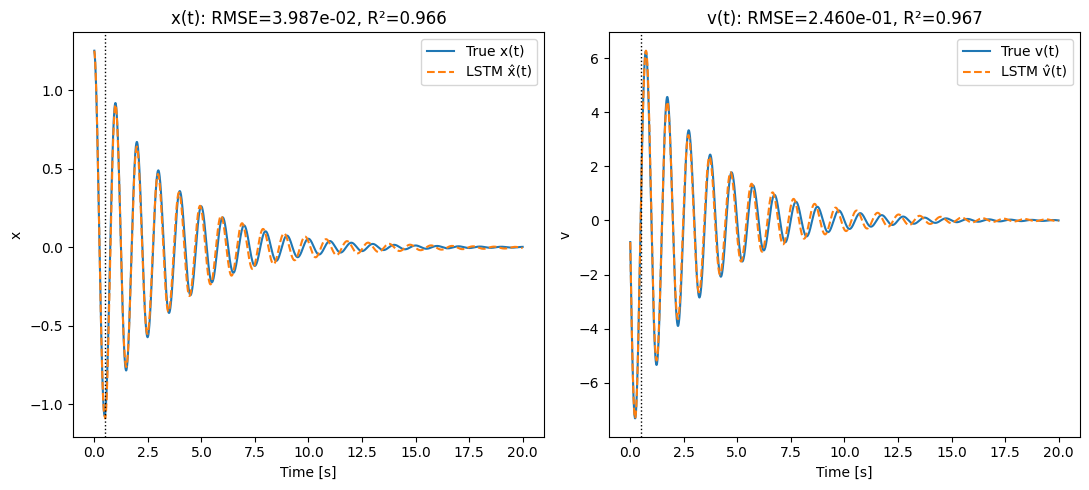

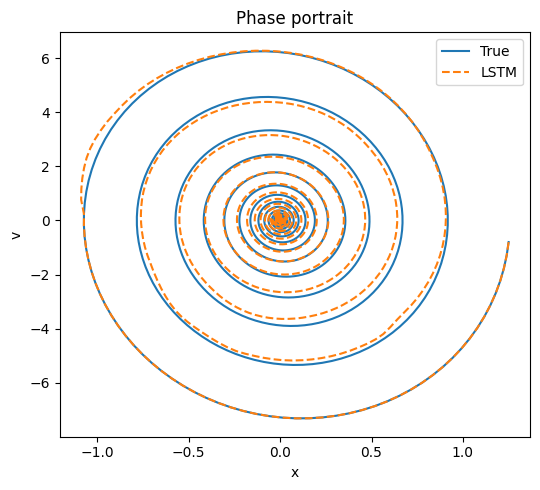

In [1]:
# lstm_over_ode.py
# Learn an ODE's flow map with an LSTM:
#   ODE: x' = v
#        v' = -2*zeta*omega0*v - omega0^2*x     (damped oscillator)
# Steps:
# 1) Generate trajectories with solve_ivp
# 2) Make supervised (windowed) sequences
# 3) Train LSTM to predict next state (x_{t+1}, v_{t+1})
# 4) Free-roll predictions and compare to the true ODE

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from scipy.integrate import solve_ivp
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ----------------------------
# 1) ODE setup and data gen
# ----------------------------
@dataclass
class ODEParams:
    omega0: float = 2.0 * np.pi * 1.0   # natural freq (rad/s), ~1 Hz
    zeta:   float = 0.05                # damping ratio

def osc_ode(t, y, p: ODEParams):
    x, v = y
    dxdt = v
    dvdt = -2.0 * p.zeta * p.omega0 * v - (p.omega0 ** 2) * x
    return [dxdt, dvdt]

def make_trajectory(p: ODEParams, x0=1.0, v0=0.0, T=20.0, dt=0.01):
    """
    Build t_eval so it stays within t_span to avoid:
    ValueError: Values in `t_eval` are not within `t_span`.
    """
    # number of whole steps that fit in T
    n = int(np.floor(T / dt + 1e-12))
    t_eval = np.linspace(0.0, n * dt, n + 1)  # last point <= T exactly

    sol = solve_ivp(
        fun=lambda t, y: osc_ode(t, y, p),
        t_span=(0.0, T),
        y0=[x0, v0],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-12
    )
    Y = np.vstack((sol.y[0], sol.y[1])).T  # shape: (len(t), 2)
    return sol.t, Y

def generate_dataset(n_traj=20, T=20.0, dt=0.01, seed=0):
    rng = np.random.default_rng(seed)
    p = ODEParams()
    all_t, all_Y = [], []
    for _ in range(n_traj):
        # random initial conditions
        x0 = rng.uniform(-2.0, 2.0)
        v0 = rng.uniform(-2.0, 2.0)
        t, Y = make_trajectory(p, x0=x0, v0=v0, T=T, dt=dt)
        all_t.append(t)
        all_Y.append(Y)
    return all_t, all_Y, p


# ----------------------------
# 2) Windowed supervised data
# ----------------------------
def make_supervised_multi(trajs, window=50, horizon=1):
    """
    Convert a list of trajectories [array(T,2), ...] into supervised pairs:
        X: (N, window, 2), past states
        Y: (N, horizon*2), next state(s) flattened
    """
    X, Y = [], []
    for Ytraj in trajs:
        for i in range(len(Ytraj) - window - horizon + 1):
            X.append(Ytraj[i:i+window, :])                         # (window, 2)
            Y.append(Ytraj[i+window:i+window+horizon, :].ravel())  # (horizon*2,)
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)
    return X, Y


# ----------------------------
# 3) Build & train LSTM
# ----------------------------
def build_lstm(window, out_dim, units=64, dropout=0.1):
    model = keras.Sequential([
        layers.Input(shape=(window, 2)),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.Dense(out_dim)  # linear output
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


# ----------------------------
# 4) Free-roll forecast helper
# ----------------------------
def freeroll(model, scaler, y_hist, steps, horizon=1):
    """
    Autoregressive rollout (in ORIGINAL scale).
    y_hist: (window, 2) most recent true states (original scale)
    steps: number of single-step predictions to produce
    Returns array shape (steps, 2)
    """
    window = y_hist.shape[0]
    out = []
    # Work in scaled space internally
    sh = scaler.transform(y_hist).astype(np.float32)
    for _ in range(steps):
        y_in = sh.reshape(1, window, 2)
        yhat_scaled = model.predict(y_in, verbose=0)[0]                  # (horizon*2,)
        yhat = scaler.inverse_transform(yhat_scaled.reshape(horizon, 2)) # (horizon,2)
        out.append(yhat[0])
        # slide window with *scaled* prediction appended
        sh = np.vstack([sh[1:], yhat_scaled.reshape(horizon, 2)])[-window:]
    return np.array(out)


# ----------------------------
# Main experiment
# ----------------------------
if __name__ == "__main__":
    # Reproducibility
    tf.random.set_seed(42)
    np.random.seed(42)

    # Sanity checks
    T      = 20.0
    dt     = 0.01
    assert dt > 0 and T > 0

    window = 50
    horizon = 1  # predict only the next state; set >1 for multi-step blocks

    # Generate multiple trajectories for training & validation
    all_t, all_Y, params = generate_dataset(n_traj=24, T=T, dt=dt, seed=123)

    # Train/val split by trajectories
    n_train = int(0.8 * len(all_Y))
    train_trajs = all_Y[:n_train]
    val_trajs   = all_Y[n_train:]

    # Scale states feature-wise (x and v jointly across all train samples)
    scaler = MinMaxScaler()
    stacked_train = np.vstack(train_trajs)  # (sum_T, 2)
    scaler.fit(stacked_train)

    train_scaled = [scaler.transform(y) for y in train_trajs]
    val_scaled   = [scaler.transform(y) for y in val_trajs]

    # Windowed supervised sets
    Xtr, Ytr = make_supervised_multi(train_scaled, window=window, horizon=horizon)
    Xva, Yva = make_supervised_multi(val_scaled,   window=window, horizon=horizon)

    # Build & train LSTM
    model = build_lstm(window=window, out_dim=2*horizon, units=96, dropout=0.1)
    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)
    ]
    history = model.fit(
        Xtr, Ytr,
        validation_data=(Xva, Yva),
        epochs=50,
        batch_size=256,
        callbacks=cbs,
        verbose=1
    )

    # ----------------------------
    # Rollout on a fresh test trajectory (not used in training)
    # ----------------------------
    # Make one more “test” trajectory
    t_te, Y_te = make_trajectory(params, x0=1.25, v0=-0.8, T=T, dt=dt)

    # Free-run prediction starting after the initial window
    init_hist = Y_te[:window, :]               # (window,2) in original scale
    steps     = len(Y_te) - window
    Y_pred    = freeroll(model, scaler, init_hist, steps=steps, horizon=horizon)

    # Reconstruct full predicted timeline (pad the history we didn't predict)
    Y_pred_full = np.vstack([init_hist, Y_pred])
    assert Y_pred_full.shape == Y_te.shape

    # Metrics over the predicted region (exclude warm-up/history)
    y_true = Y_te[window:, :]        # (steps, 2)
    y_hat  = Y_pred_full[window:, :] # (steps, 2)

    rmse_x = np.sqrt(mean_squared_error(y_true[:, 0], y_hat[:, 0]))
    rmse_v = np.sqrt(mean_squared_error(y_true[:, 1], y_hat[:, 1]))
    r2_x   = r2_score(y_true[:, 0], y_hat[:, 0])
    r2_v   = r2_score(y_true[:, 1], y_hat[:, 1])

    print(f"RMSE x: {rmse_x:.5f}   R^2 x: {r2_x:.4f}")
    print(f"RMSE v: {rmse_v:.5f}   R^2 v: {r2_v:.4f}")

    # ----------------------------
    # Plots
    # ----------------------------
    plt.figure(figsize=(11, 5))
    plt.subplot(1,2,1)
    plt.plot(t_te, Y_te[:,0], label="True x(t)")
    plt.plot(t_te, Y_pred_full[:,0], "--", label="LSTM x̂(t)")
    plt.axvline(t_te[window], color="k", ls=":", lw=1)
    plt.title(f"x(t): RMSE={rmse_x:.3e}, R²={r2_x:.3f}")
    plt.xlabel("Time [s]"); plt.ylabel("x")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(t_te, Y_te[:,1], label="True v(t)")
    plt.plot(t_te, Y_pred_full[:,1], "--", label="LSTM v̂(t)")
    plt.axvline(t_te[window], color="k", ls=":", lw=1)
    plt.title(f"v(t): RMSE={rmse_v:.3e}, R²={r2_v:.3f}")
    plt.xlabel("Time [s]"); plt.ylabel("v")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Phase portrait
    plt.figure(figsize=(5.5,5))
    plt.plot(Y_te[:,0], Y_te[:,1], label="True")
    plt.plot(Y_pred_full[:,0], Y_pred_full[:,1], "--", label="LSTM")
    plt.xlabel("x"); plt.ylabel("v")
    plt.title("Phase portrait")
    plt.legend(); plt.tight_layout(); plt.show()
